# EDA — 21 Active Matches (Train / Held-out)

Expanded analysis of the **21 matches** in `shuttleset_split.json`:
- **19 Train** (supervised shot type classification + cross-validation)
- **2 Held-out** (final evaluation)

Previously only 10 matches were used (8 train + 2 held-out). This notebook covers the full 21-match pool.

Sections:
1. Load split & CSV annotations
2. Per-split summary statistics
3. Shot type distribution (overall + per split)
4. Per-match shot counts
5. Rally length distribution
6. Shot duration (frames between consecutive hits)
7. Shot transition matrix
8. Court position heatmaps (hit / landing)
9. Skeleton & shuttle data coverage
10. Shot type balance across splits (KL divergence)
11. Player & tournament breakdown
12. Comparison: 10-match vs 21-match

In [1]:
import sys, json
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from src.config import SS_CSV_ROOT, SS_MATCH_CSV, SS_FRAMES, SS_SPLIT_JSON, SS_SKELETONS_GDINO, SS_SHUTTLES

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10
plt.rcParams['figure.facecolor'] = 'white'

SHOT_TYPE_EN = {
    '發短球': 'Short Serve',    '發長球': 'Long Serve',
    '推球':   'Push',           '撲球':   'Rush',
    '殺球':   'Smash',          '點扣':   'Tap Smash',
    '切球':   'Slice',          '過度切球': 'Trans. Slice',
    '長球':   'Clear',          '平球':   'Drive',
    '後場抽平球': 'BG Drive',   '小平球': 'Half Smash',
    '擋小球': 'Net Block',      '放小球': 'Net Drop',
    '勾球':   'Cross-Net',      '挑球':   'Lob',
    '防守回抽': 'Def. Drive',   '防守回挑': 'Def. Lob',
    '未知球種': 'Unknown',
}

SPLIT_COLORS = {'train': '#22c55e', 'held_out': '#a78bfa'}
SPLIT_LABELS = {'train': 'Train (19)', 'held_out': 'Held-out (2)'}

print("Imports OK")

Imports OK


## 1. Load Split & CSV Annotations

In [2]:
# Load split manifest
split_data = json.loads(SS_SPLIT_JSON.read_text())
active_matches = {}
for sp in ('train', 'held_out'):
    for m in split_data.get(sp, []):
        active_matches[m] = sp

print(f"Active matches: {len(active_matches)}")
for sp in ('train', 'held_out'):
    n = sum(1 for v in active_matches.values() if v == sp)
    print(f"  {sp:10s}: {n}")

# Load match metadata
match_meta = pd.read_csv(SS_MATCH_CSV)
match_meta['video'] = match_meta['video'].str.strip()
match_meta = match_meta[match_meta['video'].isin(active_matches)].copy()
match_meta['split'] = match_meta['video'].map(active_matches)
print(f"\nMatch metadata loaded: {len(match_meta)} rows")

# Load all CSV stroke annotations for these 21 matches
csv_root = Path(SS_CSV_ROOT)
all_records = []
for match_id, sp in sorted(active_matches.items()):
    match_dir = csv_root / match_id
    if not match_dir.exists():
        print(f"  [WARN] No CSV dir: {match_id}")
        continue
    for csv_path in sorted(match_dir.glob('set*.csv')):
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        df['match_id'] = match_id
        df['split'] = sp
        df['set_file'] = csv_path.name
        all_records.append(df)

strokes = pd.concat(all_records, ignore_index=True)
strokes['type_en'] = strokes['type'].map(SHOT_TYPE_EN).fillna(strokes['type'])

print(f"\nTotal strokes: {len(strokes):,}")
print(f"Columns: {list(strokes.columns)}")
strokes.head(3)

Active matches: 21
  train     : 19
  held_out  : 2

Match metadata loaded: 21 rows

Total strokes: 17,754
Columns: ['rally', 'ball_round', 'time', 'frame_num', 'roundscore_A', 'roundscore_B', 'player', 'server', 'type', 'aroundhead', 'backhand', 'hit_height', 'hit_area', 'hit_x', 'hit_y', 'landing_height', 'landing_area', 'landing_x', 'landing_y', 'lose_reason', 'win_reason', 'getpoint_player', 'flaw', 'player_location_area', 'player_location_x', 'player_location_y', 'opponent_location_area', 'opponent_location_x', 'opponent_location_y', 'db', 'match_id', 'split', 'set_file', 'type_en']


,rally,ball_round,time,frame_num,roundscore_A,roundscore_B,player,server,type,aroundhead,...,player_location_x,player_location_y,opponent_location_area,opponent_location_x,opponent_location_y,db,match_id,split,set_file,type_en
0,1,1.0,00:06:31,11754.0,1,0,A,1,發長球,NaN,...,630.0,381.0,8.0,747.0,557.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,train,set1.csv,Long Serve
1,1,2.0,00:06:32,11788.0,1,0,B,2,點扣,NaN,...,788.0,622.0,8.0,632.0,359.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,train,set1.csv,Tap Smash
2,1,3.0,00:06:34,11825.0,1,0,A,2,擋小球,NaN,...,662.0,367.0,8.0,775.0,614.0,0,Anders_Antonsen_Sameer_Verma_TOYOTA_THAILAND_O...,train,set1.csv,Net Block


## 2. Per-Split Summary Statistics

In [3]:
split_summary = strokes.groupby('split').agg(
    matches=('match_id', 'nunique'),
    rallies=('rally', 'nunique'),
    shots=('type', 'count'),
    shot_types=('type', 'nunique'),
).reindex(['train', 'held_out'])

split_summary['shots_pct'] = (split_summary['shots'] / split_summary['shots'].sum() * 100).round(1)
split_summary['avg_shots_per_rally'] = (split_summary['shots'] / split_summary['rallies']).round(1)

print("=" * 65)
print("SPLIT SUMMARY")
print("=" * 65)
print(split_summary.to_string())
print(f"\nTotal: {split_summary['matches'].sum()} matches, "
      f"{split_summary['rallies'].sum()} rallies, "
      f"{split_summary['shots'].sum():,} shots")

# Per-match breakdown
print("\n" + "-" * 65)
per_match = strokes.groupby(['split', 'match_id']).agg(
    rallies=('rally', 'nunique'),
    shots=('type', 'count'),
).reset_index().sort_values(['split', 'shots'], ascending=[True, False])

for sp in ('train', 'held_out'):
    sub = per_match[per_match['split'] == sp]
    print(f"\n{sp.upper()} ({len(sub)} matches, {sub['shots'].sum():,} shots):")
    for _, r in sub.iterrows():
        short = r['match_id'].replace('_', ' ')[:55]
        print(f"  {r['shots']:5d} shots  {r['rallies']:3d} rallies  {short}")

SPLIT SUMMARY
          matches  rallies  shots  shot_types  shots_pct  avg_shots_per_rally
split                                                                        
train          19       42  16079          19       90.6                382.8
held_out        2       40   1675          19        9.4                 41.9

Total: 21 matches, 82 rallies, 17,754 shots

-----------------------------------------------------------------

TRAIN (19 matches, 16,079 shots):
   1273 shots   42 rallies  Hans-Kristian Solberg Vittinghus Lee Cheuk Yu TOYOTA TH
   1219 shots   39 rallies  CHOU Tien Chen Jonatan CHRISTIE Indonesia Open 2019 Qua
   1204 shots   42 rallies  Anders Antonsen Sameer Verma TOYOTA THAILAND OPEN 2021 
   1200 shots   40 rallies  Ng Ka Long Angus Kidambi Srikanth HSBC BWF WORLD TOUR F
   1095 shots   40 rallies  Viktor Axelsen Anthony Sinisuka Ginting YONEX Thailand 
    951 shots   39 rallies  NG Ka Long Angus Jonatan CHRISTIE Malaysia Masters 2020
    910 shots   42 rall

## 3. Shot Type Distribution (Overall + Per Split)

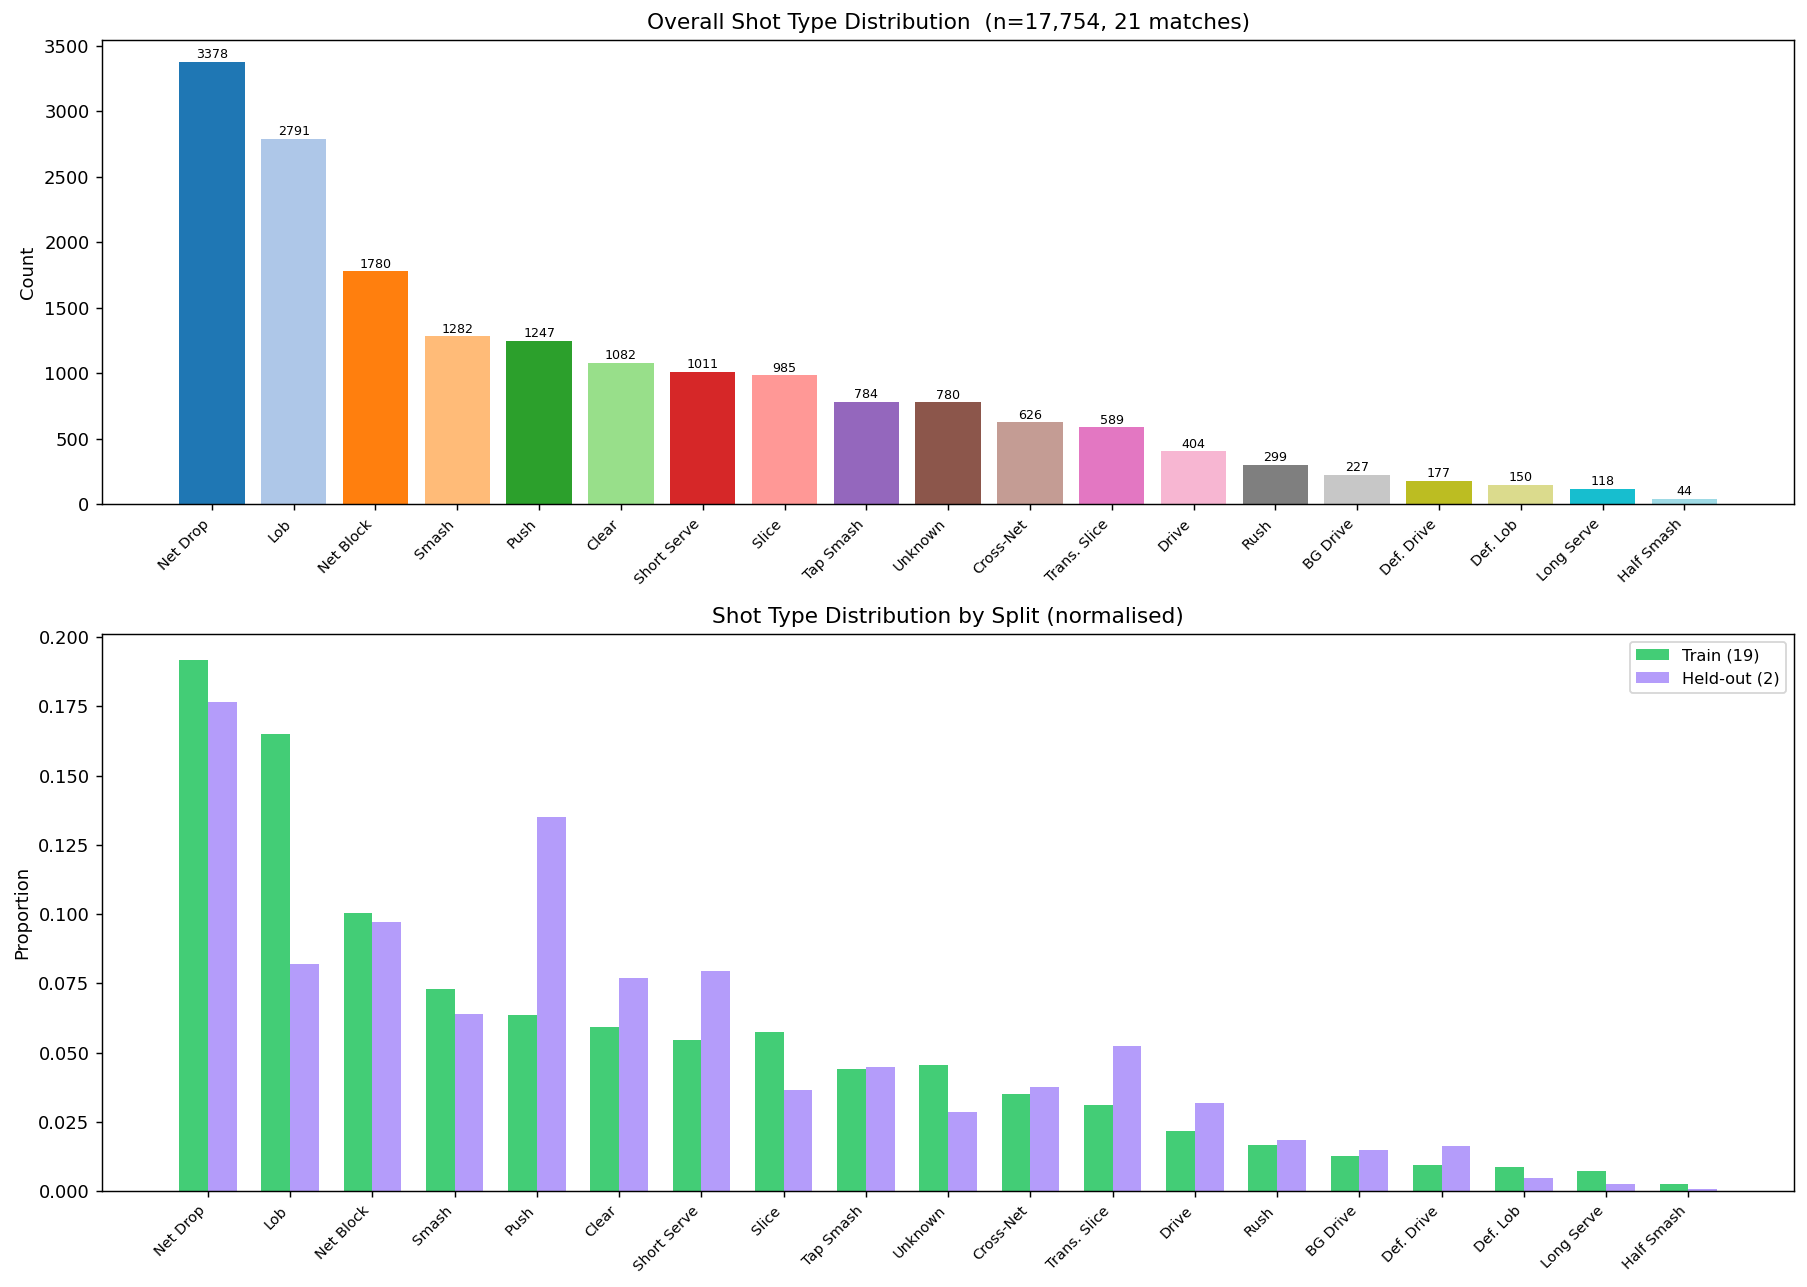

Imbalance ratio (max/min): 76.8x

Top-5 shot types:
         Net Drop:  3378  (19.0%)
              Lob:  2791  (15.7%)
        Net Block:  1780  (10.0%)
            Smash:  1282  (7.2%)
             Push:  1247  (7.0%)


In [4]:
type_counts = strokes['type'].value_counts()
en_labels = [SHOT_TYPE_EN.get(s, s) for s in type_counts.index]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

# Overall distribution
colors = plt.cm.tab20(np.linspace(0, 1, len(type_counts)))
bars = axes[0].bar(range(len(type_counts)), type_counts.values, color=colors)
axes[0].set_xticks(range(len(type_counts)))
axes[0].set_xticklabels(en_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Count')
axes[0].set_title(f'Overall Shot Type Distribution  (n={len(strokes):,}, 21 matches)')
for bar, cnt in zip(bars, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha='center', va='bottom', fontsize=7)

# Per-split (grouped bar)
split_type = strokes.groupby(['split', 'type']).size().unstack(fill_value=0)
split_type = split_type.reindex(index=['train', 'held_out'], columns=type_counts.index, fill_value=0)
# Normalise within each split
split_pct = split_type.div(split_type.sum(axis=1), axis=0)

x = np.arange(len(type_counts))
w = 0.35
for i, sp in enumerate(['train', 'held_out']):
    axes[1].bar(x + i*w - w/2, split_pct.loc[sp].values, w,
                label=SPLIT_LABELS[sp], color=SPLIT_COLORS[sp], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(en_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Proportion')
axes[1].set_title('Shot Type Distribution by Split (normalised)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print top-5 imbalance
print(f"Imbalance ratio (max/min): {type_counts.max() / type_counts.min():.1f}x")
print(f"\nTop-5 shot types:")
for shot, cnt in type_counts.head(5).items():
    print(f"  {SHOT_TYPE_EN.get(shot, shot):>15}: {cnt:>5}  ({cnt/len(strokes)*100:.1f}%)")

## 4. Per-Match Shot Counts (heatmap by shot type)

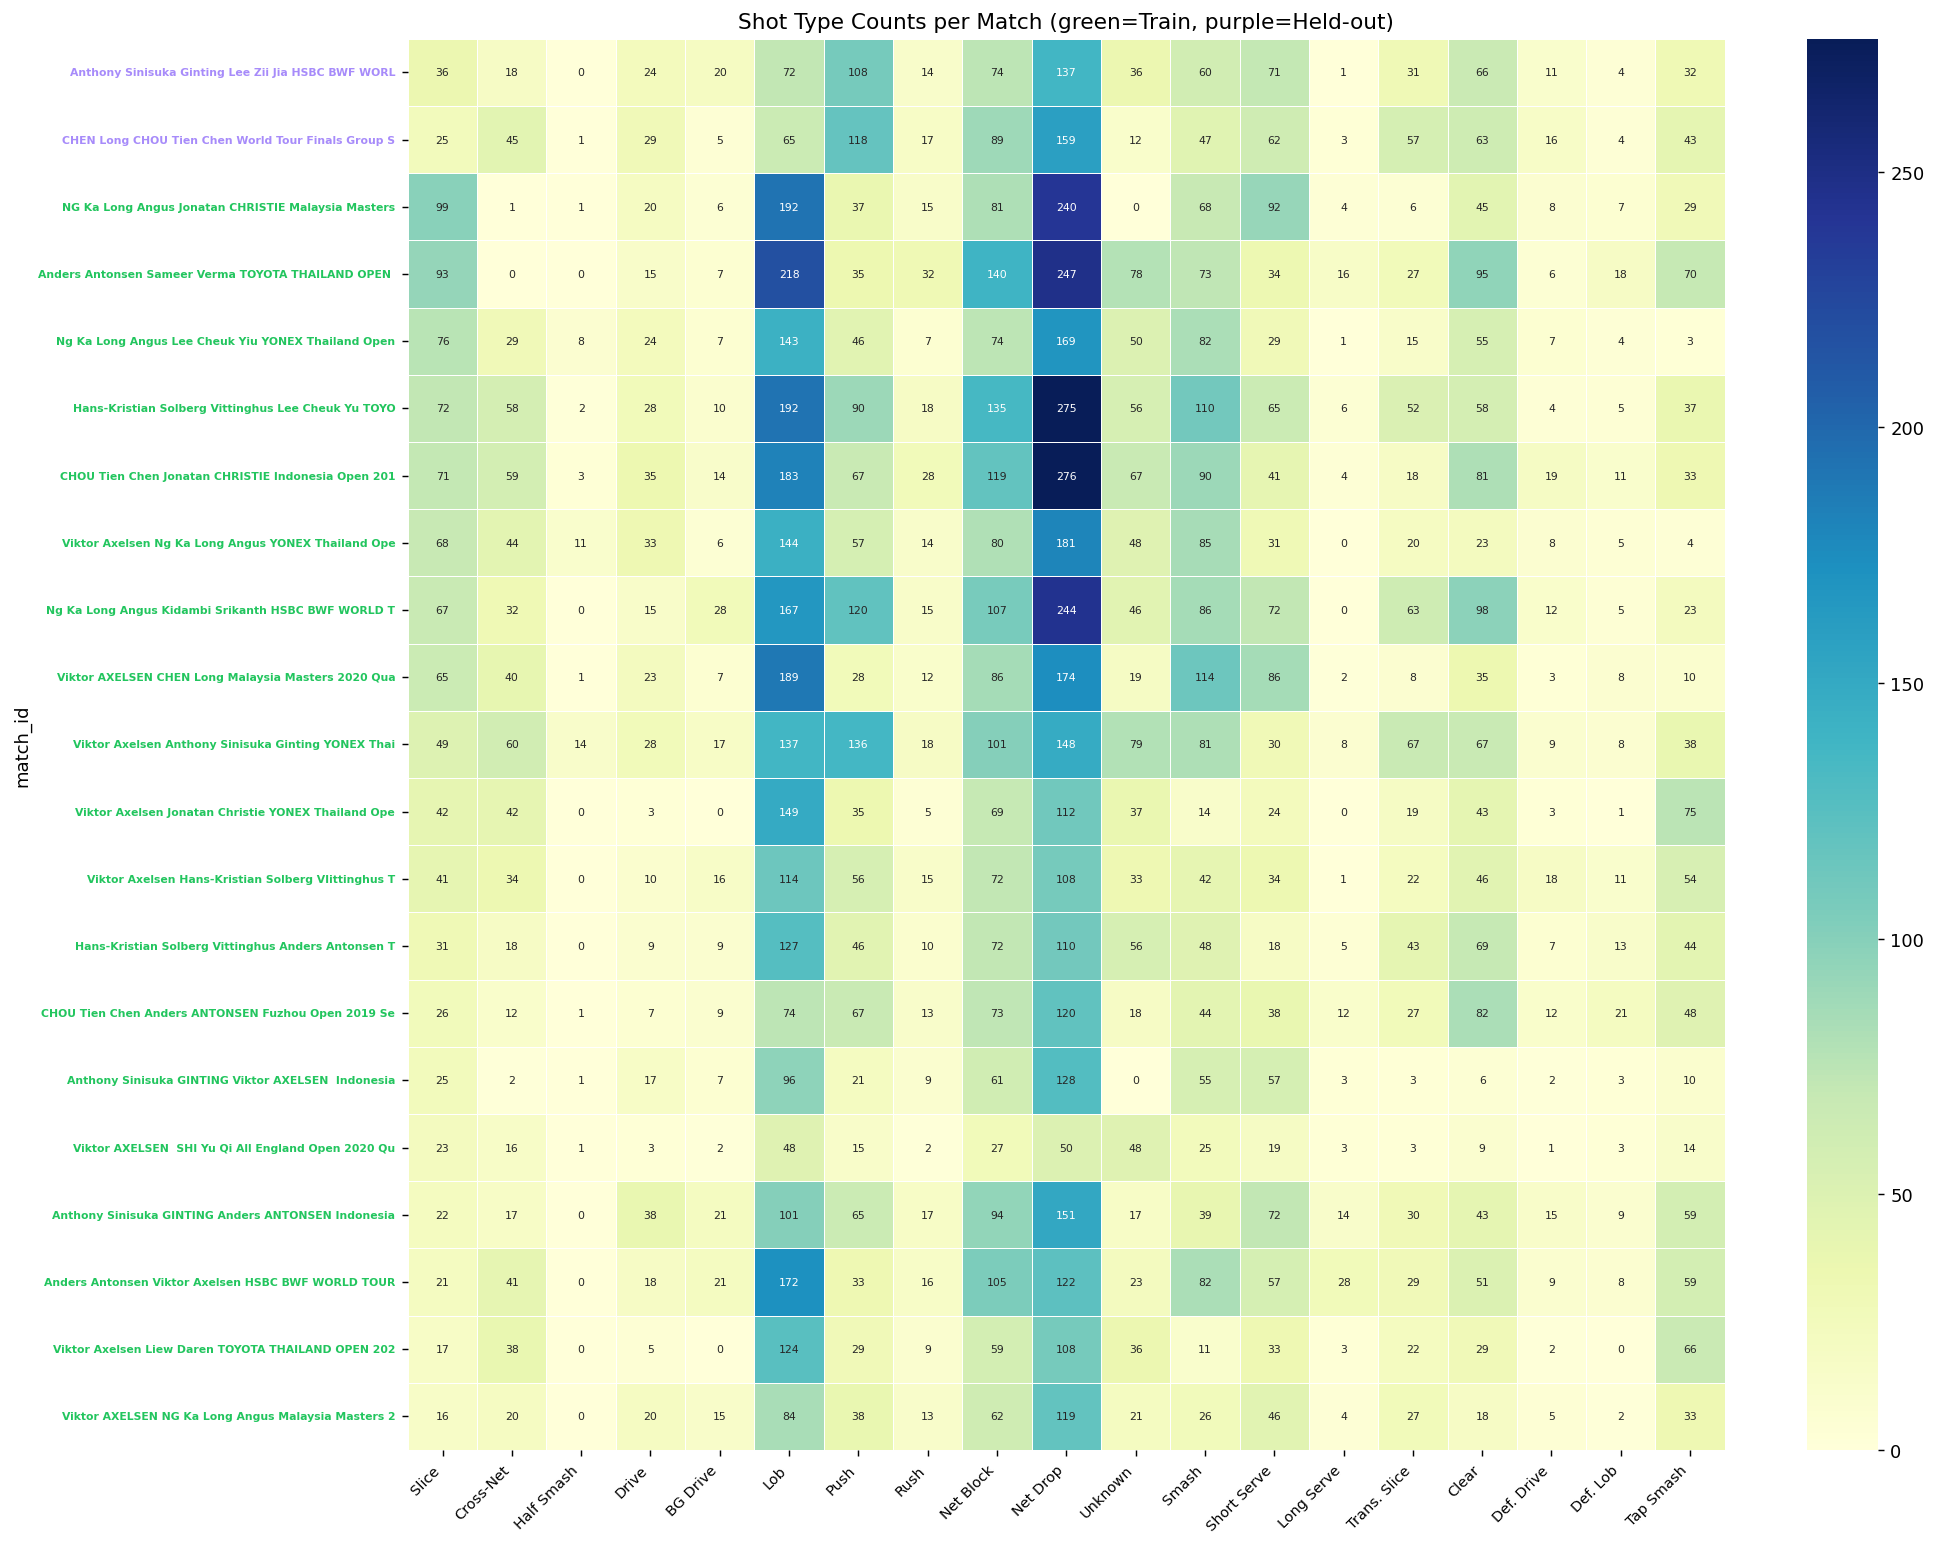

In [5]:
# Shot type heatmap per match
spm = strokes.groupby(['match_id', 'type']).size().unstack(fill_value=0)
spm.columns = [SHOT_TYPE_EN.get(c, c) for c in spm.columns]

# Add split label to index
split_map = strokes.groupby('match_id')['split'].first()
spm['_split'] = spm.index.map(split_map)
spm = spm.sort_values(['_split', spm.columns[0]], ascending=[True, False])
split_labels = spm['_split'].values
spm = spm.drop(columns='_split')

# Colour row labels by split
row_labels = [m.replace('_', ' ')[:50] for m in spm.index]
row_colors = [SPLIT_COLORS.get(s, '#888') for s in split_labels]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(spm, annot=True, fmt='d', cmap='YlGnBu',
            ax=ax, linewidths=0.3, annot_kws={'size': 6})
ax.set_yticklabels(row_labels, fontsize=6)
for i, (label, color) in enumerate(zip(ax.get_yticklabels(), row_colors)):
    label.set_color(color)
    label.set_fontweight('bold')
ax.set_title('Shot Type Counts per Match (green=Train, purple=Held-out)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Rally Length Distribution

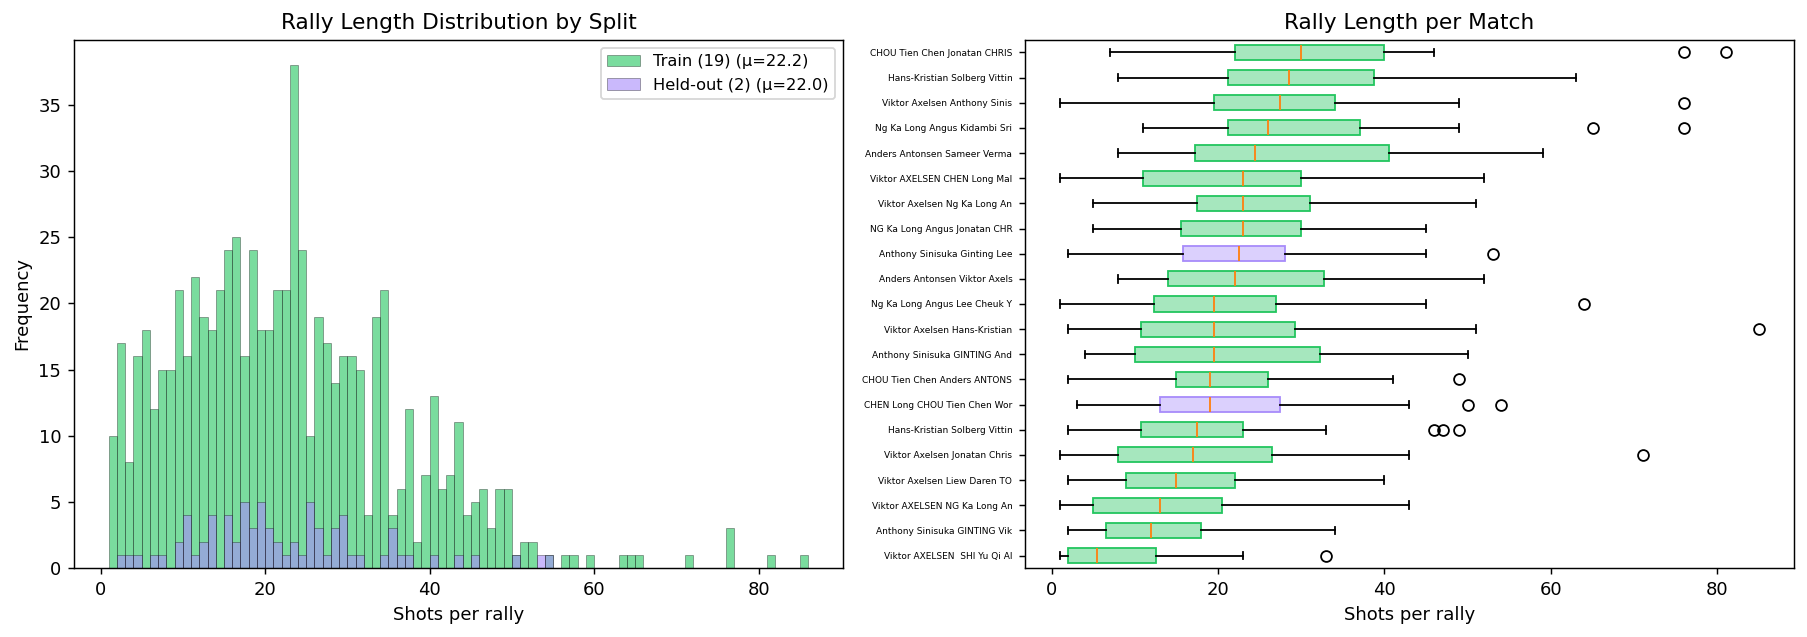

Total rallies: 800
Shots/rally — min: 1, median: 21, mean: 22.2, max: 85


In [6]:
rally_len = strokes.groupby(['split', 'match_id', 'rally']).size().reset_index(name='n_shots')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram per split
for sp in ('train', 'held_out'):
    sub = rally_len[rally_len['split'] == sp]
    axes[0].hist(sub['n_shots'], bins=range(1, rally_len['n_shots'].max() + 2),
                 alpha=0.6, label=f"{SPLIT_LABELS[sp]} (\u03bc={sub['n_shots'].mean():.1f})",
                 color=SPLIT_COLORS[sp], edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Shots per rally')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Rally Length Distribution by Split')
axes[0].legend(fontsize=9)

# Box plot per match
match_order = rally_len.groupby('match_id')['n_shots'].median().sort_values().index
bp = axes[1].boxplot(
    [rally_len[rally_len['match_id'] == m]['n_shots'].values for m in match_order],
    vert=False, patch_artist=True, widths=0.6
)
# Colour boxes by split
for i, m in enumerate(match_order):
    sp = active_matches[m]
    bp['boxes'][i].set_facecolor(SPLIT_COLORS[sp] + '66')
    bp['boxes'][i].set_edgecolor(SPLIT_COLORS[sp])
axes[1].set_yticklabels([m.replace('_', ' ')[:28] for m in match_order], fontsize=5)
axes[1].set_xlabel('Shots per rally')
axes[1].set_title('Rally Length per Match')

plt.tight_layout()
plt.show()

print(f"Total rallies: {len(rally_len)}")
print(f"Shots/rally — min: {rally_len['n_shots'].min()}, "
      f"median: {rally_len['n_shots'].median():.0f}, "
      f"mean: {rally_len['n_shots'].mean():.1f}, "
      f"max: {rally_len['n_shots'].max()}")

## 7. Shot Transition Matrix

## 6. Shot Duration (frames between consecutive hits)

In [ ]:
# Compute shot duration = frame gap between consecutive hits within a rally
# ShuttleSet is 30fps
FPS = 30

durations = []
for (match_id, rally), grp in strokes.groupby(['match_id', 'rally']):
    grp = grp.sort_values('ball_round')
    frames = grp['frame_num'].values
    types = grp['type'].values
    types_en = grp['type_en'].values
    split = grp['split'].iloc[0]
    for i in range(1, len(frames)):
        if np.isnan(frames[i]) or np.isnan(frames[i-1]):
            continue
        gap = frames[i] - frames[i-1]
        if gap <= 0:
            continue
        durations.append({
            'match_id': match_id, 'split': split,
            'shot_type': types[i], 'shot_type_en': types_en[i],
            'prev_type': types[i-1], 'prev_type_en': types_en[i-1],
            'frame_gap': gap,
            'duration_s': gap / FPS,
        })

dur_df = pd.DataFrame(durations)
print(f"Shot durations computed: {len(dur_df):,} (consecutive pairs with valid frame_num)")
print(f"Duration (seconds) — min: {dur_df['duration_s'].min():.2f}, "
      f"median: {dur_df['duration_s'].median():.2f}, "
      f"mean: {dur_df['duration_s'].mean():.2f}, "
      f"max: {dur_df['duration_s'].max():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall duration histogram
axes[0].hist(dur_df['duration_s'], bins=np.arange(0, 3.5, 0.05),
             color='#3498db', edgecolor='black', linewidth=0.3, alpha=0.85)
axes[0].axvline(dur_df['duration_s'].median(), color='red', ls='--', label=f"median={dur_df['duration_s'].median():.2f}s")
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Shot Duration Distribution (n={len(dur_df):,})')
axes[0].legend()
axes[0].set_xlim(0, 3.5)

# 2. Duration by shot type (box plot)
type_order = dur_df.groupby('shot_type_en')['duration_s'].median().sort_values(ascending=False).index
bp = axes[1].boxplot(
    [dur_df[dur_df['shot_type_en'] == t]['duration_s'].values for t in type_order],
    vert=False, patch_artist=True, widths=0.6,
    flierprops=dict(markersize=2, alpha=0.3)
)
for box in bp['boxes']:
    box.set_facecolor('#3498db55')
axes[1].set_yticklabels(type_order, fontsize=7)
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_title('Shot Duration by Shot Type')
axes[1].set_xlim(0, 4)

# 3. Duration by split
for sp in ('train', 'held_out'):
    sub = dur_df[dur_df['split'] == sp]
    axes[2].hist(sub['duration_s'], bins=np.arange(0, 3.5, 0.05),
                 alpha=0.6, label=f"{SPLIT_LABELS[sp]} (μ={sub['duration_s'].mean():.2f}s)",
                 color=SPLIT_COLORS[sp], edgecolor='black', linewidth=0.3)
axes[2].set_xlabel('Duration (seconds)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Shot Duration by Split')
axes[2].legend()
axes[2].set_xlim(0, 3.5)

plt.tight_layout()
plt.show()

# Print per-type stats
print(f"\nDuration by shot type (seconds):")
print(f"  {'Shot Type':>15s}  {'n':>5s}  {'median':>6s}  {'mean':>6s}  {'std':>5s}")
print("-" * 50)
for t in type_order:
    sub = dur_df[dur_df['shot_type_en'] == t]['duration_s']
    print(f"  {t:>15s}  {len(sub):5d}  {sub.median():6.2f}  {sub.mean():6.2f}  {sub.std():5.2f}")

In [ ]:
## 8. Court Position Heatmaps

## 7. Court Position Heatmaps

In [ ]:
## 9. Skeleton & Shuttle Data Coverage

## 8. Skeleton & Shuttle Data Coverage

In [ ]:
## 10. Shot Type Balance Across Splits (KL Divergence)

## 9. Shot Type Balance Across Splits (KL Divergence)

In [ ]:
## 11. Player & Tournament Breakdown

## 10. Player & Tournament Breakdown

In [ ]:
## 12. Comparison: 10-match vs 21-match

Quick comparison of key statistics between the original 10-match split and the expanded 21-match split.

## 11. Comparison: 10-match vs 21-match

Quick comparison of key statistics between the original 10-match split and the expanded 21-match split.

In [ ]:
# The original 10-match split (8 train + 2 held-out)
old_train = [
    'Anders_Antonsen_Viktor_Axelsen_HSBC_BWF_WORLD_TOUR_FINALS_2020_Finals',
    'Anthony_Sinisuka_GINTING_Anders_ANTONSEN_Indonesia_Masters_2020_Final',
    'Anthony_Sinisuka_GINTING_Viktor_AXELSEN _Indonesia_Masters_2020_SemiFinals',
    'CHOU_Tien_Chen_Anders_ANTONSEN_Fuzhou_Open_2019_Semi-finals',
    'Ng_Ka_Long_Angus_Lee_Cheuk_Yiu_YONEX_Thailand_Open_2021_QuarterFinals',
    'Viktor_AXELSEN _SHI_Yu_Qi_All_England_Open_2020_QuarterFinals',
    'Viktor_AXELSEN_CHEN_Long_Malaysia_Masters_2020_QuarterFinals',
    'Viktor_AXELSEN_NG_Ka_Long_Angus_Malaysia_Masters_2020_SemiFinals',
]
old_held = [
    'Anthony_Sinisuka_Ginting_Lee_Zii_Jia_HSBC_BWF_WORLD_TOUR_FINALS_2020_QuarterFinals',
    'CHEN_Long_CHOU_Tien_Chen_World_Tour_Finals_Group_Stage',
]
old_all = set(old_train + old_held)
new_only = set(active_matches.keys()) - old_all

old_strokes = strokes[strokes['match_id'].isin(old_all)]
new_strokes = strokes[strokes['match_id'].isin(new_only)]

n_train_21 = sum(1 for v in active_matches.values() if v == "train")

print("=" * 65)
print("10-MATCH vs 21-MATCH COMPARISON")
print("=" * 65)
print(f"{'':25s} {'10-match':>10s}  {'21-match':>10s}  {'Delta':>10s}")
print("-" * 65)
print(f"{'Total matches':25s} {len(old_all):10d}  {len(active_matches):10d}  {len(active_matches)-len(old_all):+10d}")
print(f"{'Train matches':25s} {len(old_train):10d}  {n_train_21:10d}  {n_train_21-len(old_train):+10d}")
print(f"{'Total shots':25s} {len(old_strokes):10,d}  {len(strokes):10,d}  {len(strokes)-len(old_strokes):+10,d}")

old_rallies = old_strokes.groupby(['match_id', 'rally']).ngroups
all_rallies = strokes.groupby(['match_id', 'rally']).ngroups
print(f"{'Total rallies':25s} {old_rallies:10d}  {all_rallies:10d}  {all_rallies-old_rallies:+10d}")

old_types = old_strokes['type'].nunique()
all_types_n = strokes['type'].nunique()
print(f"{'Unique shot types':25s} {old_types:10d}  {all_types_n:10d}  {all_types_n-old_types:+10d}")

old_players = pd.concat([match_meta[match_meta['video'].isin(old_all)]['winner'],
                         match_meta[match_meta['video'].isin(old_all)]['loser']]).nunique()
all_players_n = pd.concat([match_meta['winner'], match_meta['loser']]).nunique()
print(f"{'Unique players':25s} {old_players:10d}  {all_players_n:10d}  {all_players_n-old_players:+10d}")

print(f"\n11 newly added matches ({len(new_strokes):,} shots):")
for m in sorted(new_only):
    n = len(strokes[strokes['match_id'] == m])
    print(f"  {n:5d} shots  {m.replace('_', ' ')[:55]}")

In [ ]:
# Shot type distribution comparison: old 10-match vs new 21-match
old_type_dist = old_strokes['type'].value_counts(normalize=True)
new_type_dist = strokes['type'].value_counts(normalize=True)

# Align indices
all_shot_types = type_counts.index.tolist()
old_vals = [old_type_dist.get(t, 0) for t in all_shot_types]
new_vals = [new_type_dist.get(t, 0) for t in all_shot_types]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(all_shot_types))
w = 0.35
ax.bar(x - w/2, old_vals, w, label='10-match (original)', color='#94a3b8', alpha=0.85, edgecolor='black', linewidth=0.3)
ax.bar(x + w/2, new_vals, w, label='21-match (expanded)', color='#22c55e', alpha=0.85, edgecolor='black', linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(en_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion')
ax.set_title('Shot Type Distribution \u2014 10-match vs 21-match')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Summary

In [ ]:
# Recompute in case of kernel state issues
split_summary = strokes.groupby('split').agg(
    matches=('match_id', 'nunique'),
    rallies=('rally', 'nunique'),
    shots=('type', 'count'),
    shot_types=('type', 'nunique'),
).reindex(['train', 'held_out'])
split_summary['shots_pct'] = (split_summary['shots'] / split_summary['shots'].sum() * 100).round(1)

type_counts = strokes['type'].value_counts()
all_players = pd.concat([match_meta['winner'], match_meta['loser']]).value_counts()
rally_len = strokes.groupby(['split', 'match_id', 'rally']).size().reset_index(name='n_shots')

total_gdino = sum(1 for c in coverage if c['gdino'] == 'Yes')

print("=" * 65)
print("21-MATCH SPLIT EDA SUMMARY")
print("=" * 65)
print(f"Total matches         : {len(active_matches)}")
for sp in ('train', 'held_out'):
    n = split_summary.loc[sp]
    print(f"  {sp:10s}: {int(n['matches'])} matches, {int(n['shots']):,} shots ({n['shots_pct']}%)")
print(f"Total strokes         : {len(strokes):,}")
print(f"Total rallies         : {len(rally_len):,}")
print(f"Unique shot types     : {strokes['type'].nunique()}")
print(f"Avg shots/rally       : {rally_len['n_shots'].mean():.1f}")
print(f"Imbalance ratio       : {type_counts.max()/type_counts.min():.0f}x")
print(f"GDINO skeletons       : {total_gdino}/{len(active_matches)} matches")
print(f"Unique players        : {len(all_players)}")
print("=" * 65)